In [3]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 26.7 MB/s eta 0:00:0000:0100:01


In [3]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time

In [353]:
fn = 'SAM_AC_ncbi_soupx_cleaned_PVH_03122025.h5ad'

sam = SAM()
sam.load_data(fn)

In [354]:
sam.adata

AnnData object with n_obs × n_vars = 206 × 23671
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes', 'key', 'leiden_clusters', 'region_label', 'neurotransmitter', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'eq_clusters', 'cluster_names_pk', 'eq_supertype', 'eq_supertype_v2', 'test', 'clusters_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'SCT_snn_res.5_colors', 'dimred_indices', 'eq_clusters_colors', 'leiden_clusters_colors', 'path_to_file', 'preprocess_args', 'rank_genes_groups', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processe

In [355]:
sam.clustering(param = 2)

In [206]:
sm = load_samap('sm_hypoorgs_PVH_02182026.pkl')

In [356]:
org_two = 'ac'

In [357]:
sm.sams[org_two].clustering(param = 2)

In [358]:
keys = {'mg':'eq_supertype',org_two:'leiden_clusters'}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like='mg_')
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]

/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


In [359]:
lim_MappingTable

,mg_Avp,mg_Crh,mg_Nkx2-2,mg_Oxt,mg_Sst,mg_Trh,mg_Ucn3
ac_0,0.002014,0.046867,0.761374,0.004469,0.039593,0.004285,0.035051
ac_1,0.006212,0.003814,0.462287,0.324271,0.002708,0.000814,0.000223
ac_2,0.973130,0.004803,0.000062,0.163906,0.003339,0.000000,0.000618
ac_3,0.005038,0.000144,0.037161,0.873775,0.015061,0.000826,0.000391
ac_4,0.037381,0.295110,0.000020,0.000499,0.401913,0.030489,0.001229
ac_5,0.859525,0.005047,0.000000,0.014929,0.073124,0.001001,0.000478
ac_6,0.172882,0.014912,0.594127,0.001204,0.003941,0.000378,0.019905
ac_7,0.000264,0.006445,0.770613,0.002305,0.001767,0.005619,0.003411
ac_8,0.000344,0.275455,0.000000,0.000000,0.033598,0.439794,0.000641


In [360]:
fin_mapping = {}
for item in lim_MappingTable.index:
    bm = lim_MappingTable.loc[item,:].idxmax()
    if lim_MappingTable.loc[item,bm] > .4:
        fin_mapping[item] = bm
    else:
        fin_mapping[item] = item
        
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [361]:
sam.adata.obs['test'] = fin_labels

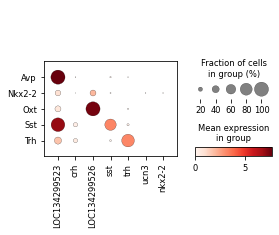

In [363]:
sc.pl.dotplot(sam.adata, groupby = 'test', var_names = ['LOC134299523','crh','LOC134299526','sst','trh','ucn3','nkx2-2'])

In [342]:
fin_mapping

{'cj_0': 'mg_Avp',
 'cj_1': 'mg_Avp',
 'cj_10': 'mg_Nkx2-2',
 'cj_11': 'mg_Oxt',
 'cj_2': 'mg_Sst',
 'cj_3': 'mg_Oxt',
 'cj_4': 'mg_Crh',
 'cj_5': 'mg_Nkx2-2',
 'cj_6': 'mg_Nkx2-2',
 'cj_7': 'mg_Trh',
 'cj_8': 'mg_Nkx2-2',
 'cj_9': 'mg_Sst'}

In [343]:
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [344]:
sam.adata.obs['eq_supertype_v2'] = fin_labels
sm.sams[org_two].adata.obs['eq_supertype_v2'] = fin_labels

In [345]:
sm.sams[org_two].adata.obs['clusters_v2'] = sam.adata.obs['leiden_clusters']
sam.adata.obs['clusters_v2'] = sam.adata.obs['leiden_clusters']

In [346]:
sam.adata.obs['eq_supertype']

AAATGGAGTTGTGGAG Run 11 sample 8       Avp
AACGAAACACTGGACC Run 11 sample 8    Nkx2-2
AACGGGAGTTGCTTGA Run 11 sample 8       Oxt
ACCAACACAGCAGTAG Run 11 sample 8       Avp
ACCATTTTCGTGCTCT Run 11 sample 8       Oxt
                                     ...  
TTTACTGAGGTACTGG Run 11 sample 7    Nkx2-2
TTTAGTCGTTGCCGAC Run 11 sample 7       Avp
TTTCCTCAGATGACCG Run 11 sample 7    Nkx2-2
TTTGATCTCTACGCAA Run 11 sample 7       Avp
TTTGGAGCATCGCTCT Run 11 sample 7       Avp
Name: eq_supertype, Length: 1016, dtype: category
Categories (5, object): ['Avp', 'Nkx2-2', 'Oxt', 'Sst', 'Trh']

In [347]:
sam.adata.obs['eq_supertype_v2'].unique()

array(['Avp', 'Nkx2-2', 'Oxt', 'Crh', 'Sst', 'Trh'], dtype=object)

In [348]:
a = 0 
fin_obs = []
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'eq_supertype'] != sam.adata.obs.loc[item,'eq_supertype_v2']:
        a += 1
        fin_obs.append(item)

In [349]:
sam.adata.obs.loc[fin_obs,'eq_supertype'].value_counts()

Avp       91
Nkx2-2    50
Sst        3
Trh        3
Oxt        0
Name: eq_supertype, dtype: int64

In [350]:
a

147

In [351]:
sam.save_anndata(fn)

In [352]:
save_samap(sm,'sm_hypoorgs_PVH_02182026.pkl')